Author: Erik Lamb

Date: 12/30/2024

Description:
This notebook preprocesses the XPCS scans by loading and cropping the images, fitting the peaks in X and Y and extracting, creating the Q-maps, and by extracting relevant information that is currently scattered between the .batchinfo files and the hdf5 files. This will output an easily readable .npz file containing all of this information for ease of analysis across other notebooks, such as xpcs and cross_correlations. Those notebooks will first check that such a file exists before beginning analysis. This is written as a notebook rather than a function because I believe it is important to visually check the data reduction is performed correctly. 

To Do:
Use 2D Gaussian fits with skewness and tilt to fit the peak instead. Save those parameters. Apply a Gaussian filter prior to fitting too. Rerun for temps up until 385

In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
from scipy.special import erf
import pyopencl as cl
from pathlib import Path
import json
import tqdm as tqdm



%matplotlib widget

# User Defined Parameters

In [2]:
### Beamline Parameters ###
Beamline = '8IDE' #P10 or 8IDE
Geometry = 'Vertical' #Horizontal or Vertical
Compound = 'NBH'

### Analysis Parameters ###


### File Parameters ###
Particle = 'A7' #2,3, A7
Temperature = 320 #[298,305,315,325,345,365,385,405,350_cool] NBH = [320,329,339,360,380,399,420]
Scan = 343 #P2: [219,334,416,552,579,709,779,796,868], P3:[239,356 NBH = [343,344,349,353,358,362,363]
Attenuation = 20

#Crop Size
#number of standard deviations from peak
Xv = 3.5
Xh = 5


New_Mask = True


# File Paths

In [3]:
# Define the path to the configuration file
config_path = Path("../configs/config_B10.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)

#This is being written to handle multiple datasets of different formatting in different locations.
#Still working out the best way to handle, but base directories are now stored in a config.json file
#Subdirectories and file names still need to be defined here due to use of f-strings
if Compound == 'NBH':
    BASE_DIR       = Path("/Users/eriklamb/data/APS/8_ID_E/Na2B10H10/") #Path(config.get("Base"))
    dataset_name   = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    subfolder      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    filename       = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_001.hdf' 
    batchname      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_0001-3000.batchinfo' 
    #Set path to working directory
    work_path      = BASE_DIR / dataset_name 
    processed_path = work_path / 'processed'
    processed = processed_path / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_NewMask{New_Mask}.h5'

#Check that path exists
if work_path.exists():
    print(f'Directory found: {work_path}')
else:
    print(f'Directory not found: {work_path}')

#Load File Names
file_list = np.sort(os.listdir(work_path)).tolist()

#Remove first element if it's DS_Store
if file_list[0] == '.DS_Store':
    file_list.remove(file_list[0])

#Removes strange file that occurs if you edit batchinfo
if file_list[0][0:2] == '._':
    file_list.remove(file_list[0])

print('Contains:') 
for f in file_list:
    print(f)

Directory found: /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A343_NaBH_att000020_320K_001
Contains:
A343_NaBH_att000020_320K_001_0001-3000.batchinfo
A343_NaBH_att000020_320K_001_001.h5
A343_NaBH_att000020_320K_001_001.hdf
processed
results


# Extract Beamline Parameters

In [4]:
if Beamline == '8IDE':
    
    metadata  = h5py.File(work_path / file_list[2], 'r') # hdf file contains metadata for the measurement
    
    batchinfo = load_batchinfo(work_path / file_list[0],'=') # batchinfo contains other parameters
    
    data      = h5py.File(work_path / file_list[1], 'r')

    try:
        #Load parameters From hdf file
        frame_spacing = np.array(metadata['/entry/instrument/detector_1/acquire_period'])
        X0            = np.array(metadata['/entry/instrument/bluesky/metadata/bcx'])
        Y0            = np.array(metadata['/entry/instrument/bluesky/metadata/bcy'])
        pixelSize     = np.array(metadata['/entry/instrument/bluesky/metadata/pix_dim_x']) #mm
        D             = np.array(metadata['/entry/instrument/bluesky/metadata/det_dist']) #sample to detector distance
        energy        = np.array(metadata['/entry/instrument/bluesky/metadata/X_energy']) #keV
        wavelength    = 10*1.2398/energy # Å
        
        #print_h5_item(metadata) uncomment to print contents
    finally: 
        #Close h5 file
        metadata.close()
    
    #Load Parameters From batchinfo
    ttheta     = batchinfo['th']
    #ccdz = batchinfo['ccdz'] #note, this is eta. Naming is ccdz for consistency with PETRA
    horBeg     = batchinfo['col_beg']
    horEnd     = batchinfo['col_end']
    verBeg     = batchinfo['row_beg']
    verEnd     = batchinfo['row_end']
    samx       = batchinfo['samx'] #this is mislabeled in the batchinfo. Actually samy
    samz       = batchinfo['samz']
    detDims    = np.array([[horBeg, horEnd],[verBeg,verEnd]]) 
    
    try:
        det = np.array(data['entry/data/data/'])[:,:,:] #Used for preprocessing
        det_corr = np.copy(det) #Used for g2 correlations
    finally:
        data.close()
    
    #X0 = batchinfo['x0'] #horizontal beam position
    #Y0 = batchinfo['y0'] #vertical beam position
    


#Remove hot pixels
det[det>100] = 0 

# Plot Speckles

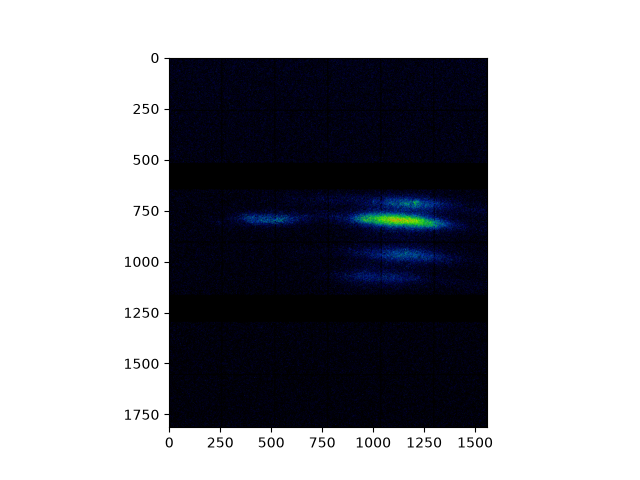

In [6]:
### Plotting ###
fig, ax = plt.subplots()

ax.imshow(np.sum(det[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))

#ax.axes.xaxis.set_visible(False)
#ax.axes.yaxis.set_visible(False)



# Fit Peak with 1D Gaussian

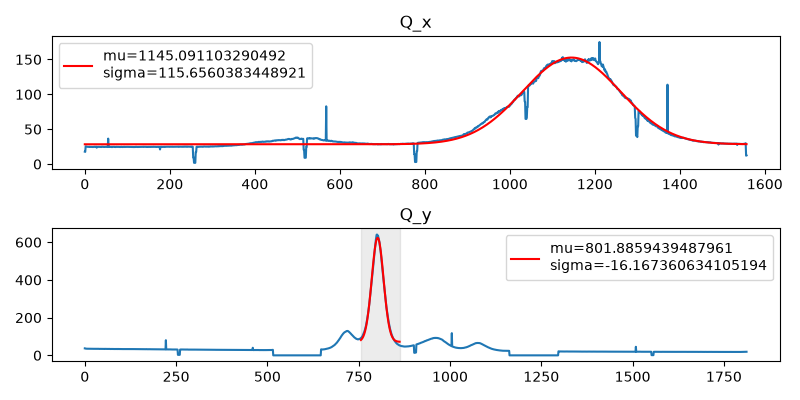

In [7]:
#Central Slice
#central_slice = det.shape[0]//2

### Sum data along both axes for fitting ###
y1 = np.sum(np.mean(det[:,:,:],axis=0),axis=0)
x1 = np.arange(y1.shape[0])

y2_full = np.sum(np.mean(det[:,:,:],axis=0),axis=1)
x2_full = np.arange(y2_full.shape[0])

# Fit the smaller Q_y peak near this pixel; keep x2 in detector coordinates
y_lo, y_hi = 756, 863
x2 = x2_full[y_lo:y_hi]
y2 = y2_full[y_lo:y_hi]

popt1, pcov1 = curve_fit(gaussian, x1, y1, p0=[np.max(y1), np.argmax(y1) , 200, np.min(y1[np.nonzero(y1)])])
popt2, pcov2 = curve_fit(gaussian, x2, y2, p0=[np.max(y2), x2[np.argmax(y2)] , 50, np.min(y2[np.nonzero(y2)])])



### Plotting ###
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 4))  # 2 rows, 1 column

# Plot on the first axis
axs[0].plot(y1)
axs[0].plot(x1, gaussian(x1, *popt1), label='mu={}\nsigma={}'.format(popt1[1],popt1[2]), color='red')
axs[0].set_title('Q_x')
axs[0].legend()

# Plot on the second axis
axs[1].plot(y2_full)
axs[1].plot(x2, gaussian(x2, *popt2), label='mu={}\nsigma={}'.format(popt2[1],popt2[2]), color='red')
axs[1].axvspan(y_lo, y_hi, color='gray', alpha=0.15)
axs[1].set_title('Q_y')
axs[1].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Fit Peak with 2D Gaussian

In [8]:
#Sum the Images for fitting
#det_sum = np.mean(det,axis=0)
det_sum = det[0,:,:]

#Find the x and y lengths of array. Note indices are flipped
xLen = det_sum.shape[1]
yLen = det_sum.shape[0]

#Create XY coordinates
x = np.arange(xLen)
y = np.arange(yLen)
x, y = np.meshgrid(x, y)

# Seed from the 1D fits (popt1 = Q_x, popt2 = Q_y) and fit only in that row window
# so the bright peak cannot pull the 2D Gaussian away from the smaller peak
col_max = popt1[1]
row_max = popt2[1]
std_col = abs(popt1[2])
std_row = abs(popt2[2])
tilt = 0

r0, r1 = y_lo, y_hi
c0 = max(0, int(col_max - 3*std_col))
c1 = min(xLen, int(col_max + 3*std_col))
det_win = det_sum[r0:r1, c0:c1]
xw, yw = np.meshgrid(np.arange(c0, c1), np.arange(r0, r1))

amp0 = det_sum[int(np.clip(np.rint(row_max), 0, yLen-1)), int(np.clip(np.rint(col_max), 0, xLen-1))]
bg0 = np.min(det_win[np.nonzero(det_win)]) if np.any(det_win) else 0.0
initial_guess = [amp0, col_max, row_max, std_col, std_row, tilt, bg0]

popt, pcov = curve_fit(gaussian_2d, (xw, yw), det_win.ravel(), p0=initial_guess)
data_fitted = gaussian_2d((x, y), *popt).reshape(det_sum.shape)

print(f'Gaussian Fit Parameters\nA: {popt[0]},\nCol: {popt[1]},\nRow: {popt[2]},\nStdX: {popt[3]},\nStdY: {popt[4]},\nTilt: {popt[5]},\nBG: {popt[6]}')
#Plotting

Gaussian Fit Parameters
A: 2.173950435298994,
Col: 1131.9906264614335,
Row: 797.848210287086,
StdX: 106.0975453629066,
StdY: 14.983978745390784,
Tilt: -0.06486147987270266,
BG: 0.054135130677385776


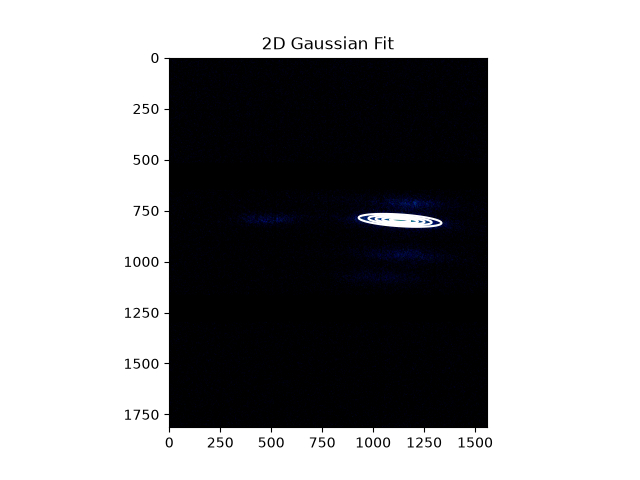

In [9]:
fig, ax = plt.subplots()

ax.imshow(det_sum+1, cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))
ax.contour(x,y,data_fitted, 5, colors='w')
plt.title('2D Gaussian Fit')
plt.show()

# Extract Mask Dimensions

In [13]:
if New_Mask == False:
    with h5py.File(mask_path, 'r') as DATA:
        mask = DATA['XPCS/Mask'][:]

    print(mask.shape[1]//2)
    print(mask.shape[2]//2)

# Crop Image

In [17]:
#Peak Locations
hCen = int(np.rint(popt1[1]))
vCen = int(np.rint(popt2[1]))

#hCen = int(np.rint(popt[1]))
#vCen = int(np.rint(popt[2]))

#print(hCen)
#print(vCen)

#Standard Deviations
hSig = int(np.rint(popt1[2]))
vSig = int(np.rint(popt2[2]))

#hSig = int(np.rint(popt[3]))
#vSig = int(np.rint(popt[4]))

angTilt = popt[5] #tilt in the distribution


#Set ROI
if New_Mask == True:
    roi = [int(vCen-Xv*vSig),int(vCen+Xv*vSig),int(hCen-Xh*hSig),int(hCen+Xh*hSig)] #vertical_1, vertical_2, horizontal_1, horizontal_2
if New_Mask == False:
    roi = [int(vCen-mask.shape[1]//2),int(vCen+mask.shape[1]//2),int(hCen-mask.shape[2]//2),int(hCen+mask.shape[2]//2)] #vertical_1, vertical_2, horizontal_1, horizontal_2

print(roi)    
#Take subset of detector
det_cropped = det[:,roi[0]:roi[1],roi[2]:roi[3]]
det_corr_cropped = det_corr[:,roi[0]:roi[1],roi[2]:roi[3]]

#ax.axes.xaxis.set_visible(False)
#ax.axes.yaxis.set_visible(False)

[858, 746, 565, 1725]


/var/folders/jg/p8s420v17f3064xm8v_n78s00000gn/T/ipykernel_25926/7770438.py:4: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(np.sum(det_cropped[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))


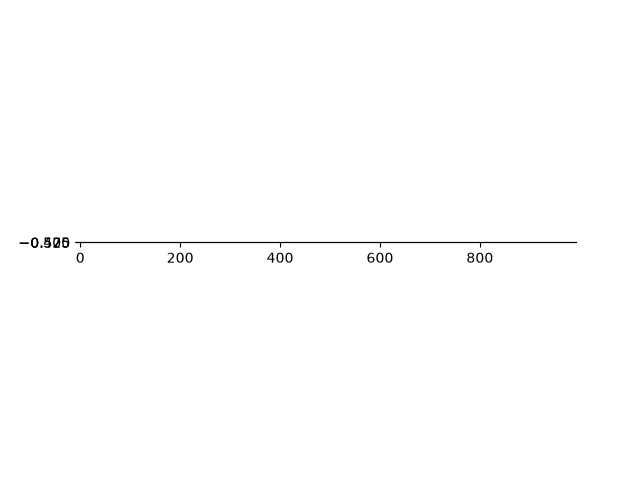

In [18]:

#Plot cropped image
fig, ax = plt.subplots()

ax.imshow(np.sum(det_cropped[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))

# Waterfall Plot

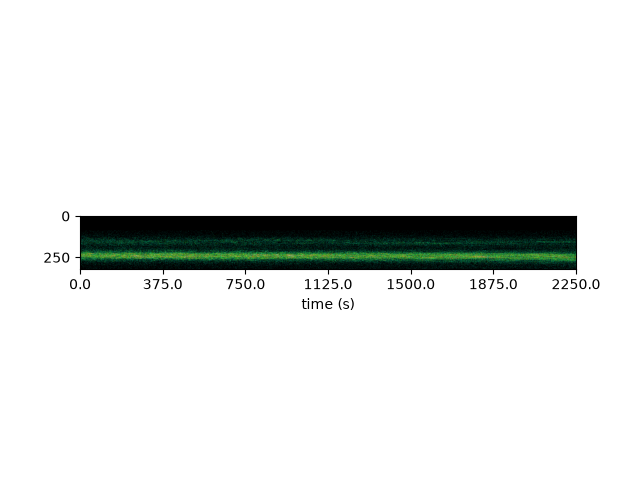

In [14]:
fig, ax = plt.subplots()

ax.imshow(det_cropped[:,:,det_cropped.shape[2]//2].T+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=6))
ax.set_xlabel('time (s)')
plt.xticks(np.arange(0,det_cropped.shape[0]+1,det_cropped.shape[0]//6), np.arange(0,det_cropped.shape[0]+1,det_cropped.shape[0]//6)*frame_spacing);

# Make GIF

<IPython.core.display.Javascript object>


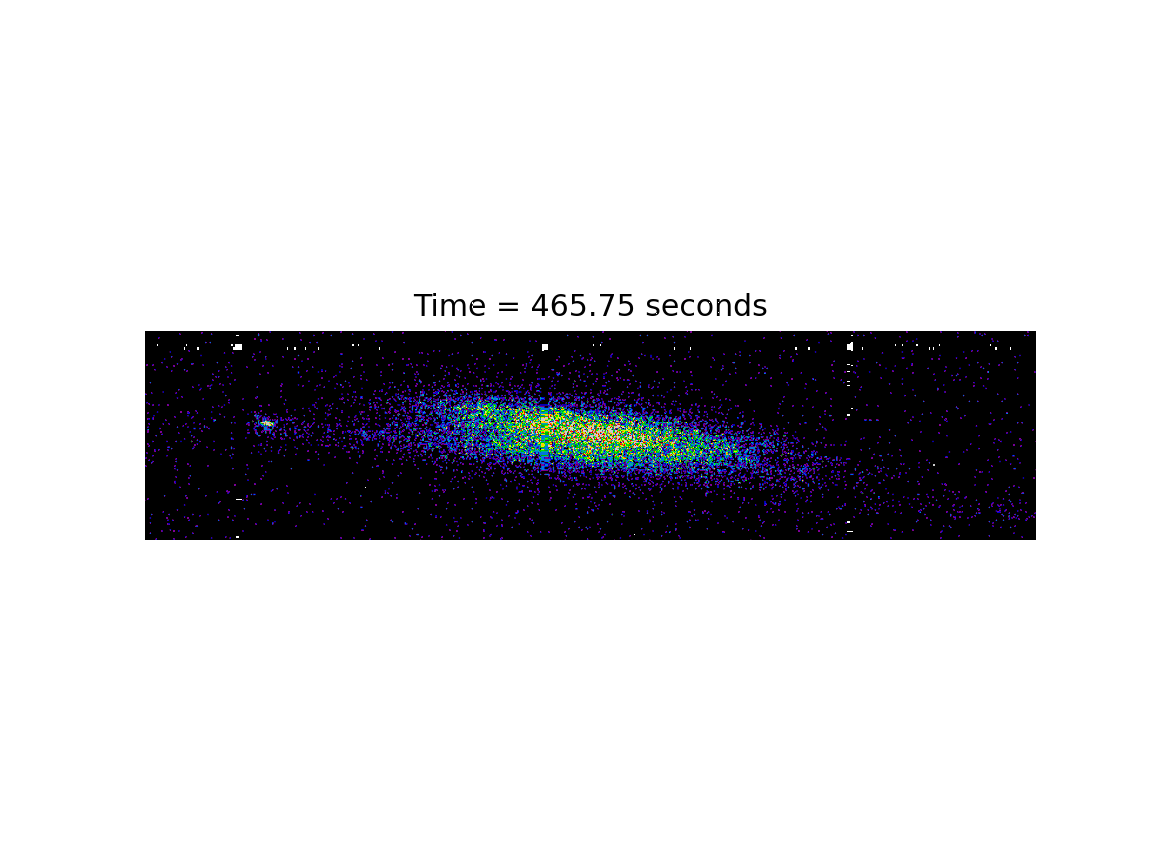

In [61]:
fps = 5

# File Path Information
if not os.path.exists(processed_path):
    os.mkdir(processed_path)
    if os.path.exists(processed_path):
        print(f"Directory '{processed_path}' created!")
        
results_name = f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_{fps}fps_NewMask{New_Mask}'
results = processed_path / results_name

#Plotting 
fig, ax = plt.subplots()

make_detector_movie(str(results), det_cropped+1, np.arange(1,det_cropped.shape[0]), frame_spacing, fig, ax, fps, scale='log', clims = [1,5])

# Calculate Q-Map

In [16]:
#Calculate shift in detector position in pixels, if any
#dpixz = int((ccdz-ccdz0)//pixelSize) #shift in pixels
#print(dpixz)

# Known Bragg 2θ (degrees): small central peak and larger peak
tth_small = 10.5745
tth_large = 10.4365

X0_meta = float(np.asarray(X0))
Y0_meta = float(np.asarray(Y0))
tth = float(np.asarray(ttheta))
pix = float(np.asarray(pixelSize))
Dist = float(np.asarray(D))

# Intensity along the cropped scan axis, used only to locate the two peaks
if Geometry == 'Horizontal':
    INT_pix = np.sum(np.mean(det_cropped, axis=0), axis=0)
else:
    INT_pix = np.sum(np.mean(det_cropped, axis=0), axis=1)

i_large = int(np.argmax(INT_pix))
INT_mask = INT_pix.copy()
half_w = max(10, INT_pix.size // 10)
INT_mask[max(0, i_large - half_w):i_large + half_w + 1] = 0
i_other = int(np.argmax(INT_mask))

# Metadata beam centers are often off. Put the Bragg peak at Qx~0 (vertical
# geometry) or Qy~0 (horizontal), then shift the other center so the two
# peak pixels land on the known 2θ values.
if Geometry == 'Vertical':
    X0 = float(hCen)
    r_large = float(roi[0] + i_large)
    r_small = float(vCen) if abs(vCen - (roi[0] + i_large)) > 5 else float(roi[0] + i_other)
    Y0_large = r_large - (Dist / pix) * np.tan(np.deg2rad(tth - tth_large))
    Y0_small = r_small - (Dist / pix) * np.tan(np.deg2rad(tth - tth_small))
    Y0 = 0.5 * (Y0_large + Y0_small)
else:
    Y0 = float(vCen)
    c_large = float(roi[2] + i_large)
    c_small = float(hCen) if abs(hCen - (roi[2] + i_large)) > 5 else float(roi[2] + i_other)
    X0_large = c_large - (Dist / pix) * np.tan(np.deg2rad(tth - tth_large))
    X0_small = c_small - (Dist / pix) * np.tan(np.deg2rad(tth - tth_small))
    X0 = 0.5 * (X0_large + X0_small)

print(f'metadata X0,Y0 = {X0_meta:.3f}, {Y0_meta:.3f}')
print(f'corrected X0,Y0 = {X0:.3f}, {Y0:.3f}')

#Calculate momentum transfer in x and y directions
#qx,qy = reciprocal_space_map(wavelength,ttheta,X0,Y0-dpixz,pixelSize,D,detDims,Geometry)
qx,qy = reciprocal_space_map(wavelength,ttheta,X0,Y0,pixelSize,D,detDims,Geometry)

#Create a meshgrid to map to the detector shpae
Qx,Qy = np.meshgrid(qx,qy)
Full_Qx = Qx
Full_Qy = Qy
#Set to same ROI as the detector
Qx = Qx[roi[0]:roi[1],roi[2]:roi[3]]
Qy = Qy[roi[0]:roi[1],roi[2]:roi[3]]


metadata X0,Y0 = 1145.000, 2041.541
corrected X0,Y0 = 1145.000, 2041.541


## Check Q-Map calculation is correct

fitted large, small 2θ = 10.4335, 10.5939
target  large, small 2θ = 10.4365, 10.5745


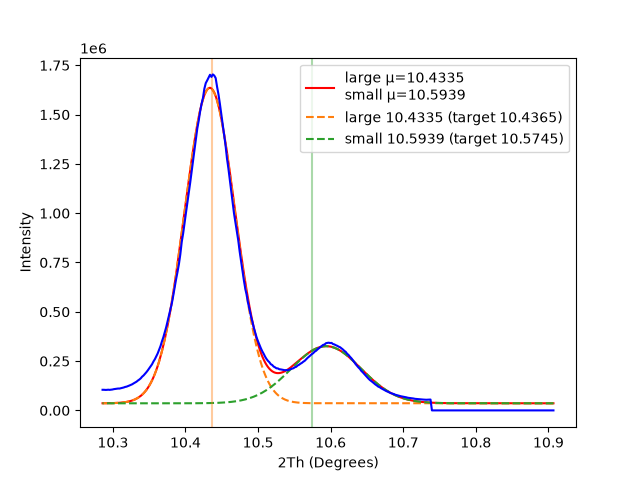

In [17]:
#TTH = q_to_tth(np.sqrt(Qx[det_cropped.shape[1]//2,:]**2+Qy[det_cropped.shape[1]//2,:]**2),wavelength)
if Geometry == 'Horizontal':
    TTH = q_to_tth(np.sqrt(Qx[det_cropped.shape[1]//2,:]**2+np.mean(Qy[:,:],axis=0)**2),wavelength)
    INT = np.sum(np.sum(det_cropped[:,:,:],axis=0),axis=0)
if Geometry == 'Vertical':
    TTH = q_to_tth(np.sqrt(Qx[:,det_cropped.shape[1]//2]**2+np.mean(Qy[:,:],axis=1)**2),wavelength)
    INT = np.sum(np.sum(det_cropped[:,:,:],axis=0),axis=1)

sig0 = 0.02
alpha0 = 0

def two_gaussians(x, A1, mu1, s1, A2, mu2, s2, c):
    return (A1*np.exp(-0.5*((x-mu1)/s1)**2)
            + A2*np.exp(-0.5*((x-mu2)/s2)**2) + c)

fitFunction = 'two_gaussian'

fig, ax = plt.subplots()

if fitFunction == 'skew_gaussian':
    lower_bounds = [-np.inf,-np.inf,-np.inf, -np.inf, 0]  # c >= 0
    upper_bounds = [np.inf, np.inf, np.inf,np.inf,np.inf]
    popt, pcov = curve_fit(skew_gaussian, TTH, INT, p0=[np.max(INT), TTH[np.argmax(INT)] , sig0,alpha0, np.min(INT[np.nonzero(INT)])],bounds=(lower_bounds, upper_bounds))
    ax.plot(TTH, skew_gaussian(TTH, *popt), label=f'mu={popt[1]}\nsigma={popt[2]}\nalpha={popt[3]}', color='red')

if fitFunction == 'gaussian':
    popt, pcov = curve_fit(gaussian, TTH, INT, p0=[np.max(INT), TTH[np.argmax(INT)] , 0.05, np.min(INT[np.nonzero(INT)])])
    ax.plot(TTH, gaussian(TTH, *popt), label=f'mu={popt[1]}\nsigma={popt[2]}', color='red')

if fitFunction == 'two_gaussian':
    i_large = int(np.argmin(np.abs(TTH - tth_large)))
    i_small = int(np.argmin(np.abs(TTH - tth_small)))
    bg = np.min(INT[np.nonzero(INT)])
    p0 = [INT[i_large], tth_large, sig0, INT[i_small], tth_small, sig0, bg]
    popt, pcov = curve_fit(two_gaussians, TTH, INT, p0=p0)
    ax.plot(TTH, two_gaussians(TTH, *popt), label=f'large μ={popt[1]:.4f}\nsmall μ={popt[4]:.4f}', color='red')
    ax.plot(TTH, gaussian(TTH, popt[0], popt[1], popt[2], popt[6]), '--', color='C1', label=f'large {popt[1]:.4f} (target {tth_large})')
    ax.plot(TTH, gaussian(TTH, popt[3], popt[4], popt[5], popt[6]), '--', color='C2', label=f'small {popt[4]:.4f} (target {tth_small})')
    ax.axvline(tth_large, color='C1', alpha=0.4)
    ax.axvline(tth_small, color='C2', alpha=0.4)
    print(f'fitted large, small 2θ = {popt[1]:.4f}, {popt[4]:.4f}')
    print(f'target  large, small 2θ = {tth_large:.4f}, {tth_small:.4f}')

ax.plot(TTH,INT,'b')
ax.set_xlabel('2Th (Degrees)')
ax.set_ylabel('Intensity')
ax.legend()


# Save Processed Data

In [20]:
#Check that path exists. Make a new one if it does not 
#Save as a compressed hdf5
if not os.path.exists(processed_path):
    os.mkdir(processed_path)
    if os.path.exists(processed_path):
        print(f"Directory '{processed_path}' created!")

if not os.path.exists(processed):
    # Save variables to the same HDF5 file
    with h5py.File(processed, 'w') as h5file:
        # Create groups
        group1 = h5file.create_group('data') #Cropped detector data
        group2 = h5file.create_group('experimental_parameters') #Information on scan/beamline parameters
        group3 = h5file.create_group('pre_processing') #Information calculated in preprocessing
        group4 = h5file.create_group('gaussian_fitting') #Results of frame by frame Gaussian fit
        
        
        # Create datasets for each variable
        group1.create_dataset('det', data=det_cropped, compression='gzip', compression_opts=9) #Cropped data with filter
        group1.create_dataset('det_corr', data=det_corr_cropped, compression='gzip', compression_opts=9) #Cropped data w/o filter

        group2.create_dataset('det_dimensions', data=detDims, compression='gzip', compression_opts=9)
        group2.create_dataset('frame_spacing', data=np.array([frame_spacing]), compression='gzip', compression_opts=9)
        group2.create_dataset('pixel_size', data=np.array([pixelSize]), compression='gzip', compression_opts=9)
        group2.create_dataset('sam_to_det', data=np.array([D]), compression='gzip', compression_opts=9) # 
        group2.create_dataset('ttheta', data=np.array([ttheta]), compression='gzip', compression_opts=9) #Detector two-theta
        group2.create_dataset('temperature', data=np.array([Temperature]), compression='gzip', compression_opts=9) #Detector two-theta
        group2.create_dataset('wavelength', data=np.array([wavelength]), compression='gzip', compression_opts=9)
        group2.create_dataset('X0', data=np.array([X0]), compression='gzip', compression_opts=9) #Beam center X position
        group2.create_dataset('Y0', data=np.array([Y0]), compression='gzip', compression_opts=9) #Beam center Y position
        group2.create_dataset('nFrames', data=np.array([det.shape[0]]), compression='gzip', compression_opts=9) #Number of frames
        group2.create_dataset('samz', data=np.array([samz]), compression='gzip', compression_opts=9) #Sample position z

        if Beamline=='P10':
            group2.create_dataset('samy', data=np.array([samy]), compression='gzip', compression_opts=9) #Sample position y
            group2.create_dataset('samth', data=np.array([samth]), compression='gzip', compression_opts=9) #Sample theta
        if Beamline=='8IDE':
            group2.create_dataset('samx', data=np.array([samx]), compression='gzip', compression_opts=9) #Sample position y

            
            
            
            
        group3.create_dataset('angular_tilt', data=np.array([angTilt]), compression='gzip', compression_opts=9) #Tilt in peak
        group3.create_dataset('hCen', data=np.array([hCen]), compression='gzip', compression_opts=9) #Horizontal center of peak
        group3.create_dataset('hSig', data=np.array([hSig]), compression='gzip', compression_opts=9) #Horizontal standard deviation
        group3.create_dataset('Qx', data=Qx, compression='gzip', compression_opts=9) #Reciprocal space map X coords
        group3.create_dataset('Qy', data=Qy, compression='gzip', compression_opts=9) #Reciprocal space map Y coords
        group3.create_dataset('Full_Qx', data=Full_Qx, compression='gzip', compression_opts=9) #Reciprocal space map X coords
        group3.create_dataset('Full_Qy', data=Full_Qy, compression='gzip', compression_opts=9) #Reciprocal space map Y coords
        group3.create_dataset('vCen', data=np.array([vCen]), compression='gzip', compression_opts=9) #Vertical center of peak
        group3.create_dataset('vSig', data=np.array([vSig]), compression='gzip', compression_opts=9) #Vertical standard deviation
        
        #group4.create_dataset('POPT', data=POPT, compression='gzip', compression_opts=9)
        #group4.create_dataset('PCOV', data=PCOV, compression='gzip', compression_opts=9)
        #group4.create_dataset('2D_time', data=t, compression='gzip', compression_opts=9)
        group4.create_dataset('TTH', data=TTH, compression='gzip', compression_opts=9)
        group4.create_dataset('INT', data=INT, compression='gzip', compression_opts=9)
        group4.create_dataset('popt', data=popt, compression='gzip', compression_opts=9)
        group4.create_dataset('pcov', data=pcov, compression='gzip', compression_opts=9)
        group4.create_dataset('popt1', data=popt1, compression='gzip', compression_opts=9)
        group4.create_dataset('popt2', data=popt2, compression='gzip', compression_opts=9)


        #group4.create_dataset('fit_function', data=np.array([fit_function]), compression='gzip', compression_opts=9)

        
    print(f"File particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_NewMask{New_Mask}_(101).h5 saved!")

File particleA7_temp320K_scan343_crop5x3.5_NewMaskTrue_(101).h5 saved!
